## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and ML Libraries

In [2]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from catboost import CatBoostRegressor



#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('../data/preprocessed/city_day_final_for_ml.csv')

#### Show Top 5 Records

In [4]:
df.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Month,Temperature,Humidity,Wind_Speed
0,Ahmedabad,83.13,107.67,6.93,28.71,33.72,17.055,6.93,49.52,59.76,209.0,Poor,1,18.5,53.6,4.2
1,Ahmedabad,79.84,107.67,13.85,28.68,41.08,17.055,13.85,48.49,97.07,328.0,Very Poor,1,22.1,52.9,4.9
2,Ahmedabad,94.52,107.67,24.39,32.66,52.61,17.055,24.39,67.39,111.33,514.0,Severe,1,18.3,52.6,7.6
3,Ahmedabad,135.99,107.67,43.48,42.08,84.57,17.055,43.48,75.23,102.70,782.0,Severe,2,19.9,58.0,8.5
4,Ahmedabad,178.33,107.67,54.56,35.31,72.80,17.055,54.56,55.04,107.38,914.0,Severe,2,18.5,46.5,6.7


#### Preparing X and Y variables

In [5]:
X = df.drop(columns=['AQI', 'AQI_Bucket'])

In [6]:
X.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Month,Temperature,Humidity,Wind_Speed
0,Ahmedabad,83.13,107.67,6.93,28.71,33.72,17.055,6.93,49.52,59.76,1,18.5,53.6,4.2
1,Ahmedabad,79.84,107.67,13.85,28.68,41.08,17.055,13.85,48.49,97.07,1,22.1,52.9,4.9
2,Ahmedabad,94.52,107.67,24.39,32.66,52.61,17.055,24.39,67.39,111.33,1,18.3,52.6,7.6
3,Ahmedabad,135.99,107.67,43.48,42.08,84.57,17.055,43.48,75.23,102.70,2,19.9,58.0,8.5
4,Ahmedabad,178.33,107.67,54.56,35.31,72.80,17.055,54.56,55.04,107.38,2,18.5,46.5,6.7


In [7]:
print("Categories in 'City' variable:     ", end=" ")
print(df['City'].unique())

print("Categories in 'AQI_Bucket' variable:  ", end=" ")
print(df['AQI_Bucket'].unique())

Categories in 'City' variable:      <StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str
Categories in 'AQI_Bucket' variable:   <StringArray>
['Poor', 'Very Poor', 'Severe', 'Moderate', 'Satisfactory', 'Good']
Length: 6, dtype: str


In [8]:
y = df['AQI']

In [9]:
y

0        209.0
1        328.0
2        514.0
3        782.0
4        914.0
         ...  
24845     41.0
24846     70.0
24847     68.0
24848     54.0
24849     50.0
Name: AQI, Length: 24850, dtype: float64

In [10]:
# Create Column Transformer
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [11]:
X = preprocessor.fit_transform(X)

In [12]:
X.shape

(24850, 39)

In [13]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((19880, 39), (4970, 39))

### Create an Evaluate Function to give all metrics after model Training

In [14]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')


Linear Regression
Model performance for Training set
- Root Mean Squared Error: 51.4568
- Mean Absolute Error: 29.3003
- R2 Score: 0.8687
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 56.1419
- Mean Absolute Error: 30.1193
- R2 Score: 0.8279


Lasso
Model performance for Training set
- Root Mean Squared Error: 52.4971
- Mean Absolute Error: 29.7909
- R2 Score: 0.8633
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 57.9826
- Mean Absolute Error: 30.6607
- R2 Score: 0.8164


Ridge
Model performance for Training set
- Root Mean Squared Error: 51.4568
- Mean Absolute Error: 29.2995
- R2 Score: 0.8687
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 56.1423
- Mean Absolute Error: 30.1182
- R2 Score: 0.8279


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 39.3931
- Mean Absolute Error: 20.5197
- R2 Score: 0.9230
---------

In [16]:

pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
7,CatBoosting Regressor,0.909942
5,Random Forest Regressor,0.909006
6,XGBRegressor,0.899360
3,K-Neighbors Regressor,0.870223
0,Linear Regression,0.827868
2,Ridge,0.827866
4,Decision Tree,0.820453
1,Lasso,0.816396
8,AdaBoost Regressor,-0.225483


### RandomForestRegressor

In [18]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the best performing model from your list
best_model = RandomForestRegressor()

# Fit the model on the training data
best_model.fit(X_train, y_train)

# Predict on the test data
y_pred_best = best_model.predict(X_test)

# Calculate and print the R2 score (Accuracy)
best_score = r2_score(y_test, y_pred_best) * 100
print("Accuracy of the best model (Random Forest) is %.2f%%" % best_score)


Accuracy of the best model (Random Forest) is 91.20%


### Plot y_pred and y_test

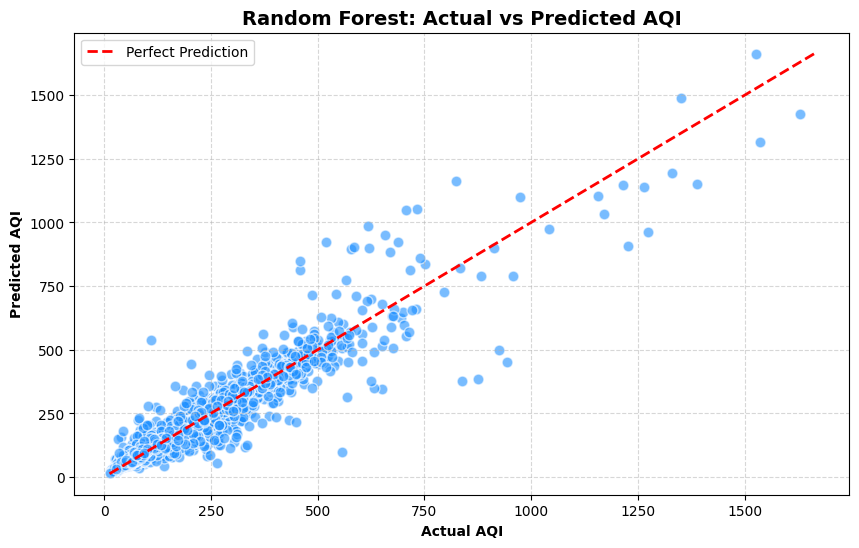

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, c='dodgerblue', edgecolors='white', s=60)

# Diagonal "Perfect Fit" line
limits = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(limits, limits, 'r--', lw=2, label='Perfect Prediction')

plt.title('Random Forest: Actual vs Predicted AQI', fontsize=14, weight='bold')
plt.xlabel('Actual AQI', weight='bold')
plt.ylabel('Predicted AQI', weight='bold')

plt.legend()
plt.grid(ls='--', alpha=0.5)
plt.show()


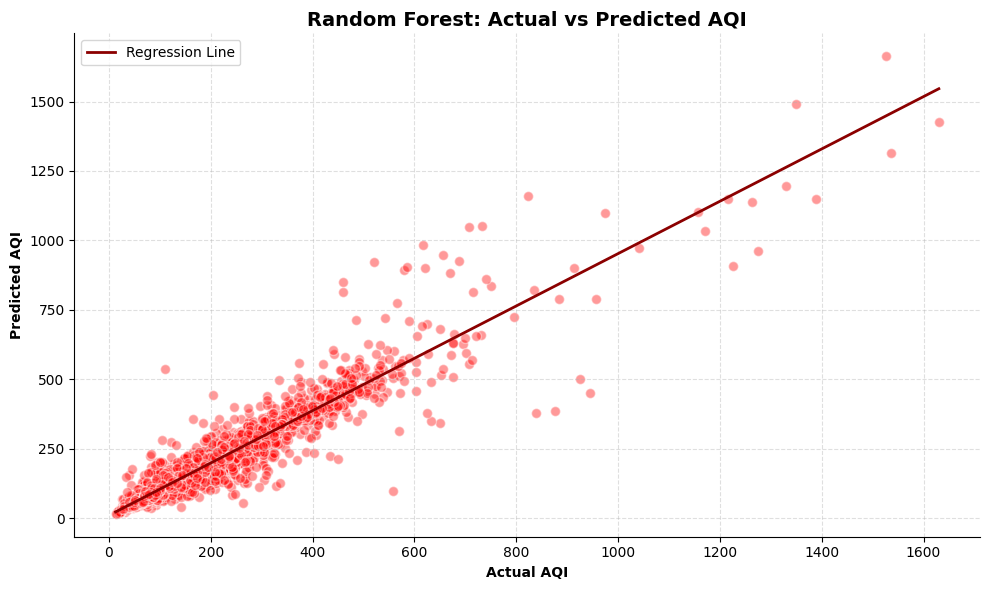

In [26]:
plt.figure(figsize=(10, 6))

sns.regplot(
    x=y_test, y=y_pred_best,
    ci=None,
    scatter_kws={'alpha': 0.4, 'color': 'red', 'edgecolors': 'white', 's': 50},
    line_kws={'color': 'darkred', 'lw': 2, 'label': 'Regression Line'}
)

plt.title('Random Forest: Actual vs Predicted AQI', fontsize=14, weight='bold')
plt.xlabel('Actual AQI', weight='bold')
plt.ylabel('Predicted AQI', weight='bold')
plt.legend()
plt.grid(ls='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()


### Difference between Actual and Predicted Values

In [28]:
pred_df = pd.DataFrame({'Actual Value': y_test, 'Predicted Value': y_pred_best, 'Difference': y_test - y_pred_best})
pred_df

,Actual Value,Predicted Value,Difference
7125,141.0,109.61,31.39
20041,209.0,213.43,-4.43
3256,111.0,104.21,6.79
18021,124.0,132.01,-8.01
5140,81.0,78.55,2.45
...,...,...,...
4973,66.0,57.79,8.21
8196,75.0,85.16,-10.16
4072,100.0,202.61,-102.61
8126,78.0,86.81,-8.81
